In [2]:
%matplotlib inline

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

> The date features provide a timestamp for when each measurement was taken. Each date column ends in a number that corresponds to the previous feature number. E.g. the value of L0_S0_D1 is the time at which L0_S0_F0 was taken.

`Id` - the uniquie id of the part

In [5]:
bosch_date = pd.read_csv('data/train_date.csv', nrows=10000)
bosch_date

,Id,L0_S0_D1,L0_S0_D3,L0_S0_D5,L0_S0_D7,L0_S0_D9,L0_S0_D11,L0_S0_D13,L0_S0_D15,L0_S0_D17,...,L3_S50_D4246,L3_S50_D4248,L3_S50_D4250,L3_S50_D4252,L3_S50_D4254,L3_S51_D4255,L3_S51_D4257,L3_S51_D4259,L3_S51_D4261,L3_S51_D4263
0,4,82.24,82.24,82.24,82.24,82.24,82.24,82.24,82.24,82.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7,1618.70,1618.70,1618.70,1618.70,1618.70,1618.70,1618.70,1618.70,1618.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,1149.20,1149.20,1149.20,1149.20,1149.20,1149.20,1149.20,1149.20,1149.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11,602.64,602.64,602.64,602.64,602.64,602.64,602.64,602.64,602.64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,19912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,19915,904.17,904.17,904.17,904.17,904.17,904.17,904.17,904.17,904.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,19917,640.60,640.60,640.60,640.60,640.60,640.60,640.60,640.60,640.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,19921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
bosch_num = pd.read_csv('data/train_numeric.csv', nrows=10000)
bosch_num

,Id,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,...,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262,Response
0,4,0.030,-0.034,-0.197,-0.179,0.118,0.116,-0.015,-0.032,0.020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,7,0.088,0.086,0.003,-0.052,0.161,0.025,-0.015,-0.072,-0.225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,9,-0.036,-0.064,0.294,0.330,0.074,0.161,0.022,0.128,-0.026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,11,-0.055,-0.086,0.294,0.330,0.118,0.025,0.030,0.168,-0.169,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,19912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9996,19915,-0.147,-0.168,-0.033,-0.016,0.074,0.161,0.030,0.128,0.056,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9997,19917,-0.095,0.004,0.330,0.312,-0.143,-0.339,0.037,0.128,0.061,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9998,19921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [14]:
bosch_date.count().sum() / bosch_date.size

np.float64(0.17792057044079515)

In [16]:
def get_station_times(dates, withId=False):
    times = []
    cols = list(dates.columns)
    if 'Id' in cols:
        cols.remove('Id')
    for feature_name in cols:
        if withId:
            df = dates[['Id', feature_name]].copy()
            df.columns = ['Id', 'time']
        else:
            df = dates[[feature_name]].copy()
            df.columns = ['time']
        df['station'] = feature_name.split('_')[1][1:]
        df = df.dropna()
        times.append(df)
    return pd.concat(times)

station_times = get_station_times(bosch_date, withId=True).sort_values(by=['Id', 'station'])

In [108]:
station_times[station_times.Id == 4].station.astype(int).value_counts().sort_index()

station
0     12
1      2
2      9
4      2
7      5
8      4
11    13
29    63
30    36
31     4
33    10
34     5
35     8
37     6
Name: count, dtype: int64

In [109]:
one_part = bosch_date[bosch_date.Id == 4].drop(columns='Id').T.dropna()
one_part

,0
L0_S0_D1,82.24
L0_S0_D3,82.24
L0_S0_D5,82.24
L0_S0_D7,82.24
L0_S0_D9,82.24
...,...
L3_S37_D3943,87.29
L3_S37_D3945,87.29
L3_S37_D3947,87.29
L3_S37_D3949,87.29


In [110]:
one_part.index = one_part.index.str.split('_', expand=True)
one_part

0
L0 S0  D1     82.24
       D3     82.24
       D5     82.24
       D7     82.24
       D9     82.24
...             ...
L3 S37 D3943  87.29
       D3945  87.29
       D3947  87.29
       D3949  87.29
       D3951  87.29

[179 rows x 1 columns]

In [111]:
one_part = one_part.reset_index()
one_part.columns = ['line', 'station', 'd', 'date']

In [112]:

one_part.line = one_part.line.str.slice(1).astype('category')
one_part

,line,station,d,date
0,0,S0,D1,82.24
1,0,S0,D3,82.24
2,0,S0,D5,82.24
3,0,S0,D7,82.24
4,0,S0,D9,82.24
...,...,...,...,...
174,3,S37,D3943,87.29
175,3,S37,D3945,87.29
176,3,S37,D3947,87.29
177,3,S37,D3949,87.29


In [113]:

one_part.station = one_part.station.str.slice(1).astype('category')
one_part

,line,station,d,date
0,0,0,D1,82.24
1,0,0,D3,82.24
2,0,0,D5,82.24
3,0,0,D7,82.24
4,0,0,D9,82.24
...,...,...,...,...
174,3,37,D3943,87.29
175,3,37,D3945,87.29
176,3,37,D3947,87.29
177,3,37,D3949,87.29


In [114]:
one_part = one_part.assign(date_rel= one_part.date - one_part.date[0])
one_part

,line,station,d,date,date_rel
0,0,0,D1,82.24,0.00
1,0,0,D3,82.24,0.00
2,0,0,D5,82.24,0.00
3,0,0,D7,82.24,0.00
4,0,0,D9,82.24,0.00
...,...,...,...,...,...
174,3,37,D3943,87.29,5.05
175,3,37,D3945,87.29,5.05
176,3,37,D3947,87.29,5.05
177,3,37,D3949,87.29,5.05


In [115]:
one_part = one_part.assign(time=one_part.date_rel * 100 * 6)
one_part

,line,station,d,date,date_rel,time
0,0,0,D1,82.24,0.00,0.0
1,0,0,D3,82.24,0.00,0.0
2,0,0,D5,82.24,0.00,0.0
3,0,0,D7,82.24,0.00,0.0
4,0,0,D9,82.24,0.00,0.0
...,...,...,...,...,...,...
174,3,37,D3943,87.29,5.05,3030.0
175,3,37,D3945,87.29,5.05,3030.0
176,3,37,D3947,87.29,5.05,3030.0
177,3,37,D3949,87.29,5.05,3030.0


In [116]:
one_part = one_part.assign(feature=one_part.d.str[1:].astype(int) - 1)
one_part

,line,station,d,date,date_rel,time,feature
0,0,0,D1,82.24,0.00,0.0,1
1,0,0,D3,82.24,0.00,0.0,3
2,0,0,D5,82.24,0.00,0.0,5
3,0,0,D7,82.24,0.00,0.0,7
4,0,0,D9,82.24,0.00,0.0,9
...,...,...,...,...,...,...,...
174,3,37,D3943,87.29,5.05,3030.0,3943
175,3,37,D3945,87.29,5.05,3030.0,3945
176,3,37,D3947,87.29,5.05,3030.0,3947
177,3,37,D3949,87.29,5.05,3030.0,3949


In [117]:
one_part = one_part.drop(columns=['date_rel', 'date', 'd'])
one_part

,line,station,time,feature
0,0,0,0.0,1
1,0,0,0.0,3
2,0,0,0.0,5
3,0,0,0.0,7
4,0,0,0.0,9
...,...,...,...,...
174,3,37,3030.0,3943
175,3,37,3030.0,3945
176,3,37,3030.0,3947
177,3,37,3030.0,3949


In [119]:
one_part = one_part[['line', 'station', 'feature', 'time']]
one_part

,line,station,feature,time
0,0,0,1,0.0
1,0,0,3,0.0
2,0,0,5,0.0
3,0,0,7,0.0
4,0,0,9,0.0
...,...,...,...,...
174,3,37,3943,3030.0
175,3,37,3945,3030.0
176,3,37,3947,3030.0
177,3,37,3949,3030.0


In [120]:
one_part[one_part.line == '0']


,line,station,feature,time
0,0,0,1,0.0
1,0,0,3,0.0
2,0,0,5,0.0
3,0,0,7,0.0
4,0,0,9,0.0
5,0,0,11,0.0
6,0,0,13,0.0
7,0,0,15,0.0
8,0,0,17,0.0
9,0,0,19,0.0


In [121]:
one_part = bosch_date[bosch_date.Id == 4].drop(columns='Id').T.dropna()
one_part.index = one_part.index.str.split('_', expand=True)
one_part = one_part.reset_index()
one_part.columns = ['line', 'station', 'd', 'date']

one_part.line = one_part.line.str.slice(1).astype('category')

one_part.station = one_part.station.str.slice(1).astype('category')
one_part = one_part.assign(date_rel= one_part.date - one_part.date[0])
one_part = one_part.assign(time=one_part.date_rel * 100 * 6)
one_part = one_part.assign(feature=one_part.d.str[1:].astype(int) - 1)
one_part = one_part.drop(columns=['date_rel', 'date', 'd'])
one_part = one_part[['line', 'station', 'feature', 'time']]


one_part

,line,station,feature,time
0,0,0,0,0.0
1,0,0,2,0.0
2,0,0,4,0.0
3,0,0,6,0.0
4,0,0,8,0.0
...,...,...,...,...
174,3,37,3942,3030.0
175,3,37,3944,3030.0
176,3,37,3946,3030.0
177,3,37,3948,3030.0


In [180]:
def get_one_part(df, id):
    return (
        df[df.Id == id]
        .drop(columns='Id')
        .T
        .dropna()
        # split "L0_S1_D2" index into a MultiIndex of ('L0', 'S1', 'D2')
        .pipe(lambda df: df.set_axis(df.index.str.split('_', expand=True)))
        # MultiIndex levels become regular columns
        .reset_index()
        # rename columns
        .set_axis(['line', 'station', 'd', 'date'], axis=1)
        # transform column values
        .assign(
            line=lambda df: df.line.str.slice(1).astype('int'),    # "L0" → 0
            station=lambda df: df.station.str.slice(1).astype('int'),  # "S1" → 1
            feature=lambda df: df.d.str[1:].astype(int) - 1,           # "D2" → 1 (0-indexed)
            time=lambda df: (df.date - df.date.iloc[0]) * 100 * 6,     # relative time in seconds
        )
        # select and reorder final columns
        .drop(columns=['date', 'd'])
        [['line', 'station', 'feature', 'time']]
    )

part_4 = get_one_part(bosch_date, 4)
part_4

,line,station,feature,time
0,0,0,0,0.0
1,0,0,2,0.0
2,0,0,4,0.0
3,0,0,6,0.0
4,0,0,8,0.0
...,...,...,...,...
174,3,37,3942,3030.0
175,3,37,3944,3030.0
176,3,37,3946,3030.0
177,3,37,3948,3030.0


In [181]:
part_4[part_4.line == '1']

,line,station,feature,time


In [182]:
part_4[part_4.line == '2']

,line,station,feature,time


In [183]:
part_4[part_4.line == '3']

,line,station,feature,time


In [184]:
part_4.line.value_counts()

line
3    132
0     47
Name: count, dtype: int64

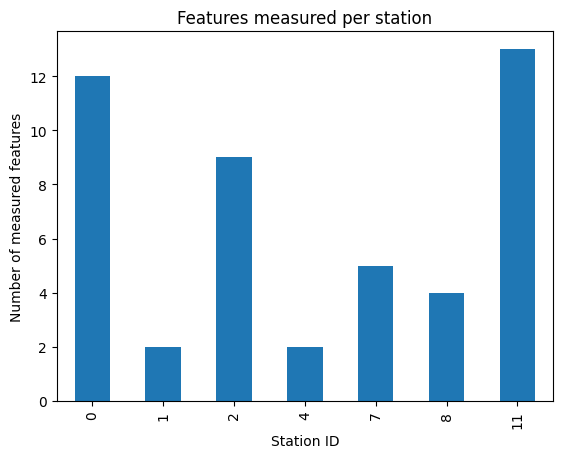

In [185]:
(part_4
 .query('line == 0')
 .station
 .value_counts()
 .sort_index()
 .plot(kind='bar', title='Features measured per station', ylabel='Number of measured features', xlabel='Station ID')
)
plt.show()


In [212]:
part6 = get_one_part(bosch_date, 6)
str(part6.head())

'   line  station  feature  time\n0     0       12      330   0.0\n1     0       12      332   0.0\n2     0       12      334   0.0\n3     0       12      336   0.0\n4     0       12      338   0.0'

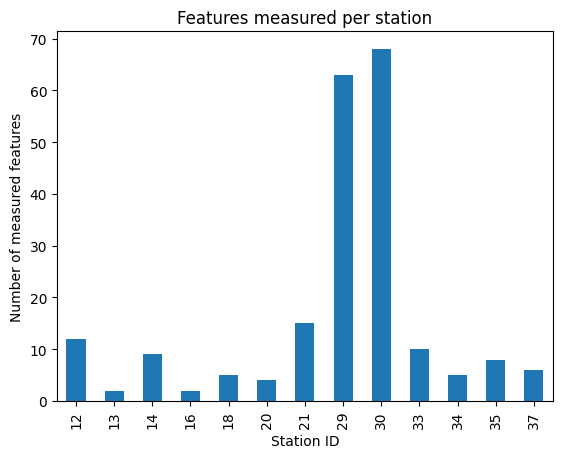

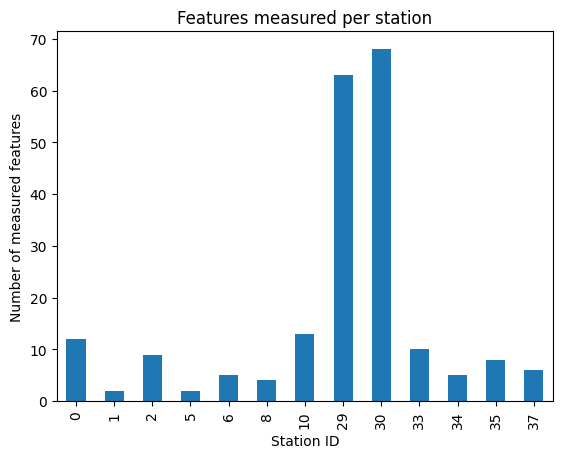

In [210]:
def plot_part(part):
    (part
     # .query('line == 0')
     .station
     .value_counts()
     .sort_index()
     .plot(kind='bar', title='Features measured per station', ylabel='Number of measured features', xlabel='Station ID')
    )

part6 = get_one_part(bosch_date, 6)
part7 = get_one_part(bosch_date, 7)

plot_part(part6)
plt.show()

plot_part(part7)
plt.show()


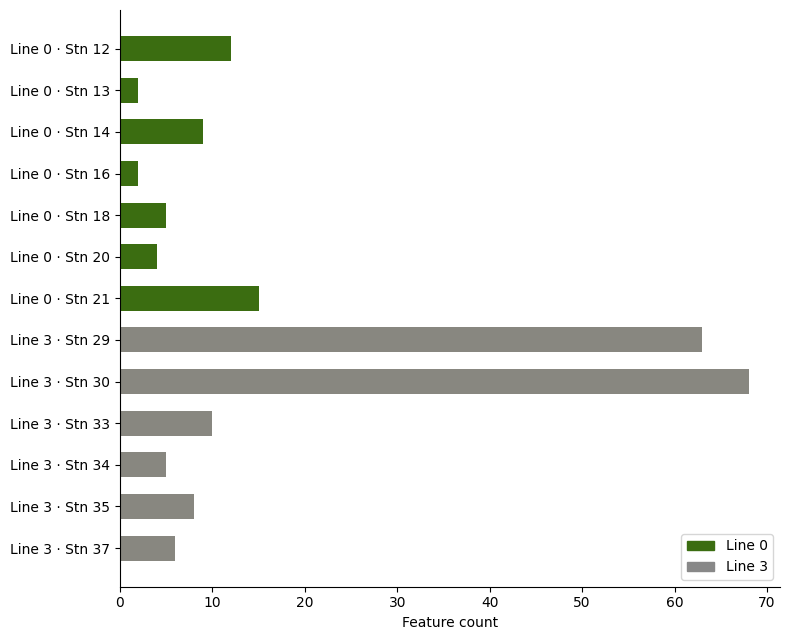

In [223]:
import matplotlib.patches as mpatches

df = part6

# Count rows per (line, station)
counts = df.groupby(['line', 'station']).size().reset_index(name='count')
counts = counts.sort_values(['line', 'station'])
#
# Build labels and assign a color per line
labels = [f"Line {r.line} · Stn {int(r.station)}" for _, r in counts.iterrows()]
values = counts['count'].tolist()
#
line_colors = {0: '#3b6d11', 1: '#185fa5', 2: '#993c1d'}  # extend as needed
colors = [line_colors.get(r.line, '#888780') for _, r in counts.iterrows()]
#
fig, ax = plt.subplots(figsize=(8, max(3, len(labels) * 0.5)))
#
bars = ax.barh(labels, values, color=colors, height=0.6)
ax.set_xlabel('Feature count')
ax.invert_yaxis()  # line 0 at top
#
# Legend per line
unique_lines = counts['line'].unique()
patches = [mpatches.Patch(color=line_colors.get(l, '#888'), label=f'Line {l}') for l in sorted(unique_lines)]
ax.legend(handles=patches, loc='lower right')

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

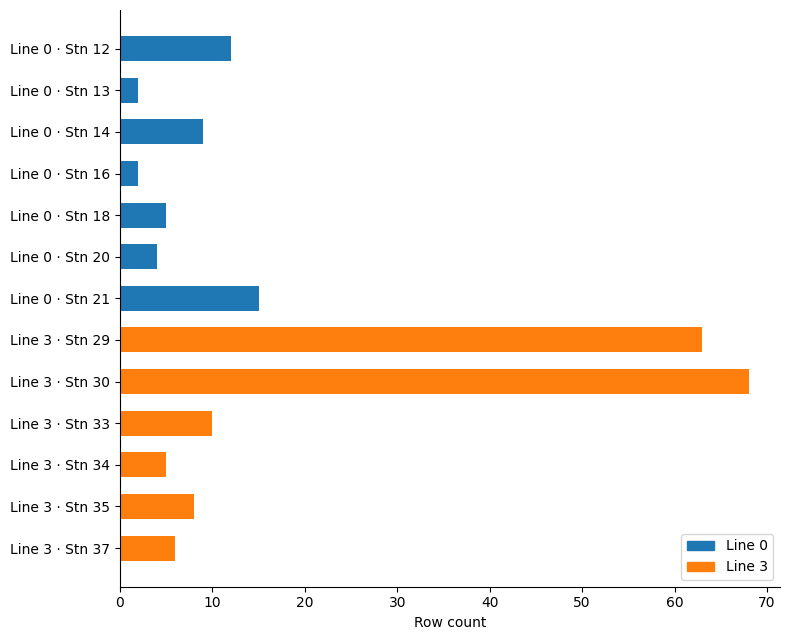

In [224]:
def plot_counts_per_line_station(df):
    counts = df.groupby(['line', 'station']).size().reset_index(name='count')
    counts = counts.sort_values(['line', 'station'])

    unique_lines = sorted(counts['line'].unique())
    cmap = plt.colormaps['tab10']
    line_colors = {l: cmap(i) for i, l in enumerate(unique_lines)}

    labels = [f"Line {r.line} · Stn {int(r.station)}" for _, r in counts.iterrows()]
    colors = [line_colors[r.line] for _, r in counts.iterrows()]

    fig, ax = plt.subplots(figsize=(8, max(3, len(labels) * 0.5)))
    ax.barh(labels, counts['count'], color=colors, height=0.6)
    ax.set_xlabel('Row count')
    ax.invert_yaxis()

    patches = [mpatches.Patch(color=line_colors[l], label=f'Line {l}') for l in unique_lines]
    ax.legend(handles=patches, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_counts_per_line_station(part6)

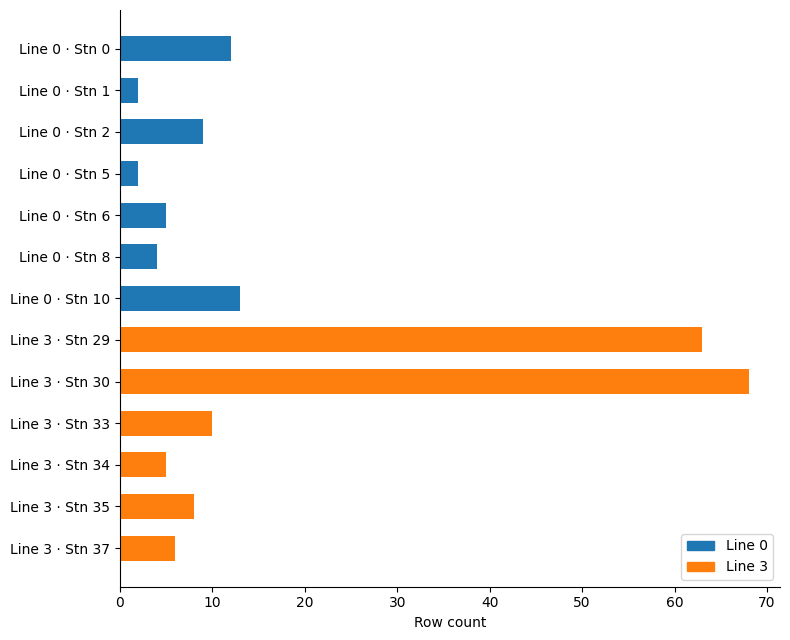

In [225]:
plot_counts_per_line_station(part7)


## Response

In [243]:
y_train = pd.read_csv('data/train_numeric.csv', usecols=['Response'])
y_train

,Response
0,0
1,0
2,0
3,0
4,0
...,...
1183742,0
1183743,0
1183744,0
1183745,0


In [244]:
y_train.value_counts()

Response
0           1176868
1              6879
Name: count, dtype: int64

In [245]:
y_train.query('Response == 1').index

Index([    539,     633,     681,     887,    1152,    1731,    1759,    2028,
          2469,    2479,
       ...
       1182795, 1182803, 1182922, 1182924, 1182925, 1183037, 1183052, 1183093,
       1183242, 1183337],
      dtype='int64', length=6879)

In [236]:
bad_part_ids = y_train.query('Response == 1').index
bad_parts = pd.read_csv('data/train_numeric.csv', skiprows=lambda x: x not in bad_part_ids)

In [241]:
bad_parts.columns = bosch_num.columns
bad_parts

,Id,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,...,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262,Response
0,1248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1792,0.030,0.041,-0.179,-0.197,0.118,0.070,-0.015,-0.072,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2346,-0.114,-0.161,0.330,0.330,-0.013,0.116,0.045,0.288,0.036,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,3523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6873,2366097,-0.062,-0.064,0.312,0.330,0.031,-0.203,0.030,0.128,-0.010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6874,2366122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6875,2366208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6876,2366504,-0.036,0.026,-0.179,-0.179,0.074,0.161,-0.007,-0.072,0.112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [242]:
bad_parts.Response

0       0
1       0
2       0
3       0
4       0
       ..
6873    0
6874    0
6875    0
6876    0
6877    0
Name: Response, Length: 6878, dtype: int64